# ANU - TP5 Optimisation

B. Boutin, Y. Le Hénaff et M. Bouchereau

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## I - Gradient à pas fixe

Cette première partie propose d'implémenter la méthode du gradient à pas fixe afin de résoudre des systèmes linéaires de la forme

\begin{equation}
    Ax=b,
\end{equation}

où $A\in\mathcal{M}_d(\mathbb{R})$ est une matrice symétrique, via l'optimisation de fonctionnelle quadratique suivante:

\begin{equation}
    J(x) = \frac12\langle Ax | x \rangle - \langle b | x \rangle.
\end{equation}

On utilise pour cela la méthode du gradient à pas fixe:

\begin{equation}
    x_{k+1} = x_k - \rho\nabla J(x_k)
\end{equation}

### 1 - Etude générale

On se propose d'implémenter la méthode du gradient à pas fixe afin de résoudre un tel système.



**Q1 -** Ecrire une fonction permettant de résoudre un système linéaire de cette forme via le gradient à pas fixe. On veillera à ce que la méthode s'arrête lorsque le nombre d'itérations ne dépasse pas un seuil maximal et/ou lorsque que la suite $(\nabla J(x_k))_{k\in\mathbb{N}} = (Ax_k-b)_{k\in\mathbb{N}}$ ne varie presque plus. Cette fonction devra retourner les itérations $x_0,x_1,\cdots,x_N$ et la solution approchée $x_N$ où $N$ est le nombre d'itérations.

Tester cette fonction dans le cas suivant:

$$A = \begin{bmatrix}
        1 & 0 \\
        0 & \frac{1}{20}
        \end{bmatrix} , \hspace{10mm} b = \begin{bmatrix}
                                            1 \\
                                            \frac{1}{10} 
                                           \end{bmatrix}$$
                                           
en prenant $\rho = 1$, $\verb|Max_iter| = 1000$ et $\verb|tol| = 10^{-8}$. Représenter l'erreur $\|Ax_k-b\|$ en échelle logarithmique ($\log\|Ax_k-b\|$ en fonction de $k$, les itérations). Procéder de même en prenant $\rho = 0.5$ et $\rho = 1.5$.

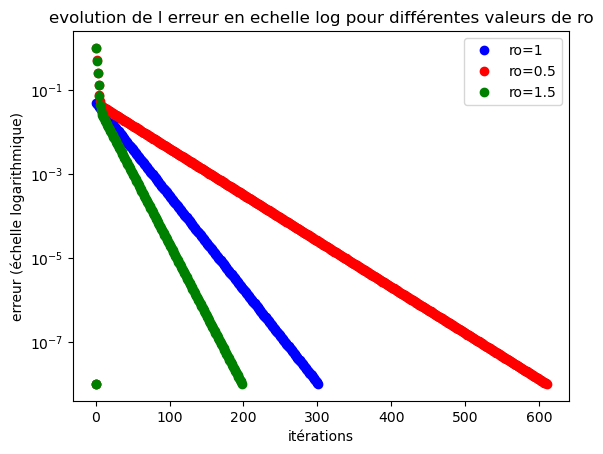

In [32]:
import numpy as np
import matplotlib.pyplot as plt

A=np.array([[1,0],[0,1/20]])
b=np.array([1,1/10])

def J(x):
    return (1/2)*np.dot(np.dot(A,x),x)-np.dot(b,x)

nbriter=0
Maxiter=1000
tol=10**(-8)
x1=[np.array([3,3])]
err1=[np.linalg.norm(np.dot(A,x[len(x)-1])-b)]
ro=1
   
while nbriter<Maxiter and np.linalg.norm(np.dot(A,x1[len(x1)-1])-b)>tol:
    x1.append(x1[len(x1)-1]-ro*(np.dot(A,x1[len(x1)-1])-b))
    nbriter+=1
    err1.append(np.linalg.norm(np.dot(A,x1[len(x1)-1])-b))
    #print(nbriter)
#print(x1[len(x1)-1])


ro2=0.5
nbriter=0
x2=[np.array([3,3])]
err2=[np.linalg.norm(np.dot(A,x[len(x)-1])-b)]
   
while nbriter<Maxiter and np.linalg.norm(np.dot(A,x2[len(x2)-1])-b)>tol:
    x2.append(x2[len(x2)-1]-ro2*(np.dot(A,x2[len(x2)-1])-b))
    nbriter+=1
    err2.append(np.linalg.norm(np.dot(A,x2[len(x2)-1])-b))
    #print(nbriter)
#print(x2[len(x2)-1])

ro3=1.5
nbriter=0
x3=[np.array([3,3])]
err3=[np.linalg.norm(np.dot(A,x[len(x)-1])-b)]
   
while nbriter<Maxiter and np.linalg.norm(np.dot(A,x3[len(x3)-1])-b)>tol:
    x3.append(x3[len(x3)-1]-ro3*(np.dot(A,x3[len(x3)-1])-b))
    nbriter+=1
    err3.append(np.linalg.norm(np.dot(A,x3[len(x3)-1])-b))
    #print(nbriter)
#print(x3[len(x3)-1])

plt.plot(np.arange(0,len(x1)),err1,'bo',label='ro='+str(ro))
plt.plot(np.arange(0,len(x2)),err2,'ro',label='ro='+str(ro2))
plt.plot(np.arange(0,len(x3)),err3,'go',label='ro='+str(ro3))
plt.yscale('log')
plt.xlabel('itérations')
plt.ylabel('erreur (échelle logarithmique)')
plt.legend()
plt.title('evolution de l erreur en echelle log pour différentes valeurs de ro')
plt.show()


### 2 - Application: Laplacien discret 1D

On se propose d'utiliser cette méthode du gradient à pas fixe résolvant un système linéaire afin de résoudre de manière approchée le problème aux limites suivant:

$$-u''(x) = f(x) , \hspace{4mm} x \in [0,1], \hspace{4mm} u(0) = u(1) = 0.$$

Pour cela, on discrétise l'intervalle $[0,1]$ en $(x_j)_{0 \leqslant j \leqslant J}$ tels que, pour tout $0 \leqslant j \leqslant J$, $x_j=\frac{j}{J}$ ($x_0=0$, $x_1 = \frac{1}{J}$,..., $x_J=1$). On note $u_j$ la solution approchée de $u$ au point $x_j$: $u_j \approx u(x_j)$. On résout donc le système:

$$J^2\begin{bmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \ddots & \vdots \\
0 & \ddots & \ddots & \ddots & 0 \\
\vdots & \ddots & -1 & 2 & -1 \\
0 & \cdots & 0 & -1 & 2
\end{bmatrix} \begin{bmatrix}
u_1 \\
u_2 \\
\vdots \\
\vdots \\
u_{J-1}
\end{bmatrix} = \begin{bmatrix}
f(x_1) \\
f(x_2) \\
\vdots \\
\vdots \\
f(x_{J-1})
\end{bmatrix},$$

et, par hypothèse, on a automatiquement $u_0 = u_J = 0$.

**Q2-** Résoudre cette équation à l'aide de la méthode du gradient à pas fixe. On prendra $f(x) = \pi^2\sin(\pi x)$, $J=100$, $\rho = 10^{-5}$, $\verb|Max_iter| = 10^6$ ,$\verb|tol| = 10^{-5}$. Tracer la solution exacte, donnée par $u_{ex}(x) = \sin(\pi x)$. 

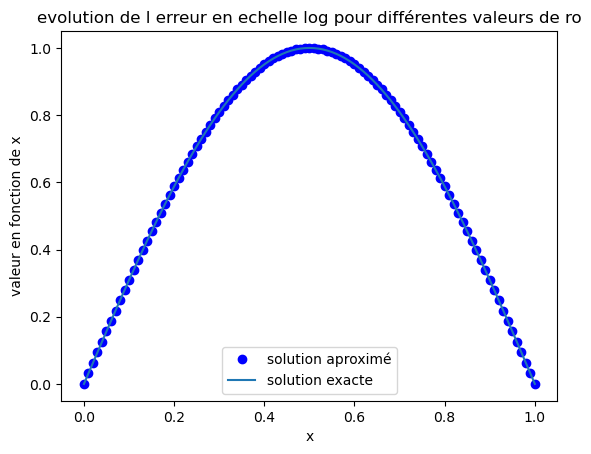

In [55]:
from math import *

def f(x):
    return ((pi)**2)*sin(pi*x)

J=100
x=[i/J for i in range (0,J+1)]
ro=10**(-5)
Maxiter=10**6
tol=10**(-5)

A=2*np.eye(J-1)+np.diag(np.ones(J-2)*(-1),1)+np.diag(np.ones(J-2)*(-1),-1)
u=[np.random.randint(10, size=(J-1))]
b=[f(xj) for xj in x]
del b[-1]
del b[0]
b=np.array(b)
err=[np.linalg.norm(np.dot(A*(J**2),u[len(u)-1])-b)]
nbriter=0

while nbriter<Maxiter and np.linalg.norm(np.dot(A*(J**2),u[len(u)-1])-b)>tol:
    u.append(u[len(u)-1]-ro*(np.dot(A*(J**2),u[len(u)-1])-b))
    nbriter+=1
    err.append(np.linalg.norm(np.dot(A*(J**2),u[len(u)-1])-b))
    #print(nbriter)
#print(u[len(u)-1])
(u[len(u)-1])=(u[len(u)-1]).tolist()
(u[len(u)-1]).append(0)
(u[len(u)-1]).insert(0,0)
#print(u[len(u)-1])
plt.plot(x,(u[len(u)-1]),'bo',label='solution aproximé')
plt.plot(x,[sin(pi*e) for e in x],label='solution exacte')
plt.xlabel('x')
plt.ylabel('valeur en fonction de x')
plt.legend()
plt.title('evolution de l erreur en echelle log pour différentes valeurs de ro')
plt.show()

## II - Régression & moindres carrés

On peut appliquer l'optimisation afin de résoudre des problèmes aux moindres carrés. ce procédé peut en particulier être utilisé afin d'étudier un problème de régression.

### 1 - Régression polynomiale

Connaissant une suite de points $(x_1,y_1),(x_2,y_2),\cdots,(x_n,y_n)$, on cherche à lier les $x_i$'s et les $y_i$'s par une relation polynomiale, autrement dit, s'il existe des réels $a_0,\cdots,a_d$ tels que, pour tout $1 \leqslant i \leqslant n$:

$$y_i = a_0 + a_1x_i + \cdots + a_dx_i^d.$$

Cela conduit donc à un système de la forme:

$$\underbrace{\begin{bmatrix}
1 & x_1 & \cdots & x_1^d \\
1 & x_2 & \cdots & x_2^d \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_n & \cdots & x_n^d
\end{bmatrix}}_{:=X\in\mathcal{M}_{n,d+1}(\mathbb{R})} \cdot \underbrace{\begin{bmatrix}
a_0 \\
a_1 \\
\vdots \\
a_d
\end{bmatrix}}_{:=\alpha\in\mathbb{R}^{d+1}} = \underbrace{\begin{bmatrix}
y_0 \\
y_1 \\
\vdots \\
y_n
\end{bmatrix},}_{:=Y\in\mathbb{R}^{n}}$$

soit alors $X\alpha = Y$. Lorsque $d \ll n$ (ce qui est en général vrai puisque nous avons beaucoup de données à traiter), un tel système n'admet en général pas de solution, on dit qu'il est surdéterminé. On recherche donc $\alpha \in \mathbb{R}^{d+1}$ minimisant la quantité:

$$E(\alpha) = \|X\alpha-Y\|^2.$$

On montre facilement que:

$$\nabla E(\alpha) = 2(X^TX\alpha - X^TY).$$

on peut donc trouver le $\alpha$ optimal via la suite:

$$\alpha_{k+1} = \alpha_k - \rho\nabla E(\alpha_k).$$

**Q3 -** En s'inspirant de la fonction créée en question **Q1**, créer une fonction prenant en entrée des listes de données $(x_i)_{1 \leqslant i \leqslant n}$ et $(y_i)_{1 \leqslant i \leqslant n}$ et réalisant une régression polynomiale entre ces données. pour construire la matrice $X$, on pourra utiliser la fonction $\verb|np.concatenate|$. Tester sur les séries de données suivantes dans le cas $d=1$:

In [3]:
x = np.array([0.0 , 1.0 , 2.0 , 3.0 , 4.0])
y = np.array([-2.0 , -1.0 , 0.0 , 1.0 , 2.0])

On prendra $\rho = 10^{-2}$, $\verb|Max_iter| = 1000$ ,$\verb|tol| = 10^{-8}$.

### 2 - La loi d'Ohm

La loi d'Ohm permet de faire le lien entre la tension aux bornes d'une resistance et l'intensité la traversant. Si on note $R$ la valeur de la résistance, $U$ la tension aux bornes de la résistance et $I$ l'intensité la traversant, alors on a:

$$ U = R \times I$$.

On mesure les tensions et intensités suivantes (repectivement en Volts et Ampères):

In [4]:
U = np.array([0.085 , 0.187 , 0.4 , 0.52 , 0.71 , 0.785 , 1.02])
I = np.array([0.012 , 0.021 , 0.045 , 0.049 , 0.067 , 0.08 , 0.11])

**Q4 -** Déterminer la valeur de la resistance $R$ par régérssion linéaire. Tracer $U$ en fonction de $I$ sur un graphe, ainsi que la droite obtenue par régression linéaire. On prendra $\rho = 10^{-1}$, $\verb|Max_iter| = 10^5$ ,$\verb|tol| = 10^{-8}$. On comparera les résultats avec la méthode $\verb|np.polyfit|$.

### 3 - Trajectoire d'un ballon

Un ballon, lancé depuis une hauteur $y_0$ avec une vitesse initiale $v_0$ et selon un angle $\theta$, et soumis uniquement à la force de pesanteur (on ne prend pas en compte les effets dûs aux frottements de l'air), décrit une trajectoire parabolique dont l'expression de l'altitude $y(t)$ au cours du temps est décrite par l'expression suivante:

$$y(t) = -\frac12 gt^2 + v_0\sin(\theta)t + y_0,$$

où $g = 9.81 m.s^{-2}$ est l'accélération de la pensanteur. On fait les relevés d'altitude suivants au cours du temps, toutes les 100 millisecondes:

In [5]:
t = np.array([0.0 , 0.1 , 0.2 , 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 , 1.0])
y = np.array([1.84 , 2.15 , 2.31 , 2.45 , 2.48 , 2.36 , 2.19 , 1.92 , 1.49 , 1.05 , 0.44])

**Q5 -** En utilisant la fonction créée en question **Q3**, trouver l'équation de la trajectoire en fonction du temps (on se placera ainsi dans le cas $d=2$). On prendra $\rho = 10^{-2}$, $\verb|Max_iter| = 10^5$ ,$\verb|tol| = 10^{-8}$. En supposant que le ballon a été lancé avec un angle $\theta = 45°$, quelle est la vitesse initiale du ballon ? Représenter $t$ et $y$ sur un graphe, ainsi que la parabole obtenuer par régression polynomiale. Comparer les résultats obtenus en utilisant la fonction $\verb|np.polyfit|$